# Part 4: Manual Gradient Descent Code Implementation
---
By Michael Nwuju

This notebook shows my **full code** for manual gradient descent on a tiny linear regression problem. I start from the raw math (loss, gradients), then loop to update `m` and `b`, plot the results, and finally check my work with SciPy.

### Problem Setup

| Parameter | Value |
|-----------|-------|
| Initial `m` | -1 |
| Initial `b` | 1 |
| Learning rate | 0.01 |
| Data points | (1, 3) and (3, 6) |
| Iterations | 2000 |

Note: For this exercise, I intend to run many iterations (2000) in order to achieve convergence.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple

x_train = np.array([1, 3]).reshape(1, 2)
y_train = np.array([3, 6]).reshape(1, 2)


m: float = -1
b: float = 1

learning_rate: float = 0.01
iterations: int = 2000

### Loss & Error Functions

In [11]:
def loss(m: float, b: float, x: np.ndarray, y: np.ndarray) -> np.ndarray:
    y_pred = m * x + b

    return y_pred - y


def mean_squared_error(m: float, b: float, x: np.ndarray, y: np.ndarray) -> float:
    return float(np.mean(loss(m, b, x, y) ** 2))


initial_mse = mean_squared_error(m, b, x_train, y_train)
print(f"Initial MSE (m={m}, b={b}): {initial_mse:.4f}")

Initial MSE (m=-1, b=1): 36.5000


## Section 2 — Gradients

We use the chain rule to get the gradients of the cost with respect to `m` and `b`.
Both are computed in a vectorized way using NumPy dot products and sums.

In [12]:
def gradient_m(loss: np.ndarray, x: np.ndarray) -> float:
    return float((2.0 / x.shape[1]) * np.dot(x, loss.T))


def gradient_b(loss: np.ndarray) -> float:
    return float((2.0 / loss.shape[1]) * np.sum(loss))

## Section 3 — Gradient Descent Loop

In each iteration we:
1. calculate the loss,
2. calculate the gradients for `m` and `b`,
3. update `m` and `b` using the learning rate.

In [13]:
def gradient_descent(
    m_start: float,
    b_start: float,
    x: np.ndarray,
    y: np.ndarray,
    learning_rate: float,
    iterations: int,
    convergence_difference: float = 1e-6,
) -> Tuple[float, float, dict]:
    m: float = m_start
    b: float = b_start

    history = {
        "m": [m],
        "b": [b],
        "error": [mean_squared_error(m, b, x, y)],
    }

    header = f"{'Iter':>4}  {'m':>10}  {'b':>10}  {'dJ/dm':>10}  {'dJ/db':>10}  {'MSE':>10}"
    print(header)
    print(f"{0:>4}  {m:>10.6f}  {b:>10.6f}  {'-':>10}  {'-':>10}  {history['error'][0]:>10.6f}")

    for i in range(1, iterations + 1):
        loss_i = loss(m, b, x, y)
        grad_m_i = gradient_m(loss_i, x)
        grad_b_i = gradient_b(loss_i)

        m = m - (learning_rate * grad_m_i)
        b = b - (learning_rate * grad_b_i)

        error_i = mean_squared_error(m, b, x, y)

        history["m"].append(m)
        history["b"].append(b)
        history["error"].append(error_i)

        print(f"{i:>4}  {m:>10.6f}  {b:>10.6f}  {grad_m_i:>10.6f}  {grad_b_i:>10.6f}  {error_i:>10.6f}")

        if abs(history["error"][-2] - error_i) < convergence_difference:
            break

    return m, b, history


print("\nGradient descent run:")
m_final, b_final, history = gradient_descent(
    m_start=m,
    b_start=b,
    x=x_train,
    y=y_train,
    learning_rate=learning_rate,
    iterations=iterations,
)

print(f"\nFinal m = {m_final:.6f}, b = {b_final:.6f}")
print(f"Final MSE = {history['error'][-1]:.6f}")


Gradient descent run:
Iter           m           b       dJ/dm       dJ/db         MSE
   0   -1.000000    1.000000           -           -   36.500000
   1   -0.730000    1.110000  -27.000000  -11.000000   28.495400
   2   -0.491400    1.207000  -23.860000   -9.700000   22.248140
   3   -0.280540    1.292516  -21.086000   -8.551600   17.372397
   4   -0.094187    1.367887  -18.635336   -7.537128   13.567058
   5    0.070517    1.434297  -16.470317   -6.640972   10.597117
   6    0.216093    1.492790  -14.557647   -5.849340    8.279164
   7    0.344772    1.544291  -12.867908   -5.150047    6.470055
   8    0.458523    1.589614  -11.375116   -4.532330    5.058076
   9    0.559086    1.629481  -10.056311   -3.986679    3.956036
  10    0.647998    1.664528   -8.891213   -3.504693    3.095890
  11    0.726618    1.695317   -7.861904   -3.078950    2.424531
  12    0.796143    1.722346   -6.952555   -2.702895    1.900511
  13    0.857635    1.746054   -6.149184   -2.370735    1.491482
  

/tmp/ipython-input-1754/809263951.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return float((2.0 / x.shape[1]) * np.dot(x, loss.T))


## Section 4 — Final Predictions

We use the final `m` and `b` to predict `y` values for the training `X` in a vectorized way.

In [14]:
def predict(m: float, b: float, x: np.ndarray) -> np.ndarray:
    return m * x + b


y_pred = predict(m_final, b_final, x_train)

print("Predictions with final m and b:", y_pred)

Predictions with final m and b: [[3.01570998 5.99349271]]


## Section 5 - Plot 1: `m` and `b` Over Iterations

Simple line plots to see how `m` and `b` change as the error (MSE) goes down.

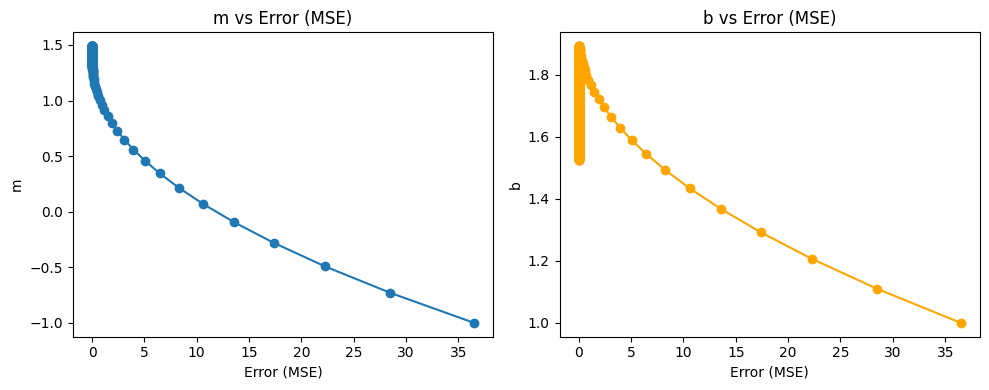

In [15]:
def plot_parameters(history: dict) -> None:
    errors = np.array(history["error"])
    m_values = np.array(history["m"])
    b_values = np.array(history["b"])

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].plot(errors, m_values, marker="o")
    axes[0].set_title("m vs Error (MSE)")
    axes[0].set_xlabel("Error (MSE)")
    axes[0].set_ylabel("m")

    axes[1].plot(errors, b_values, marker="o", color="orange")
    axes[1].set_title("b vs Error (MSE)")
    axes[1].set_xlabel("Error (MSE)")
    axes[1].set_ylabel("b")

    plt.tight_layout()
    plt.show()


plot_parameters(history)

---
## Section 6 — Plot 2: Error (MSE) Over Iterations

Line plot of the MSE values over the iterations.

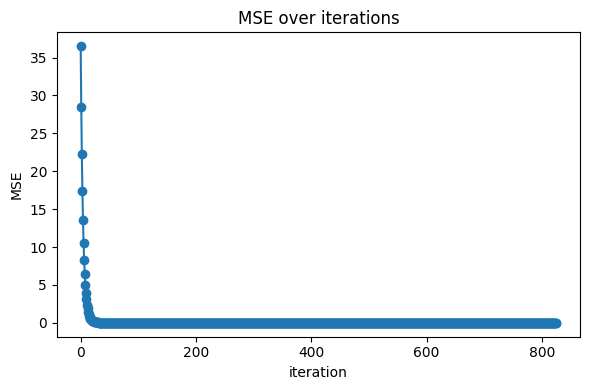

In [16]:
def plot_error(history):
    iterations = np.arange(len(history["error"]))
    errors = np.array(history["error"])

    plt.figure(figsize=(6, 4))
    plt.plot(iterations, errors, marker="o")
    plt.title("MSE over iterations")
    plt.xlabel("iteration")
    plt.ylabel("MSE")
    plt.tight_layout()
    plt.show()


plot_error(history)

## Section 7 - Line of Best fit

Use final `m` and `b` to plot line of best fit so we see both points connect

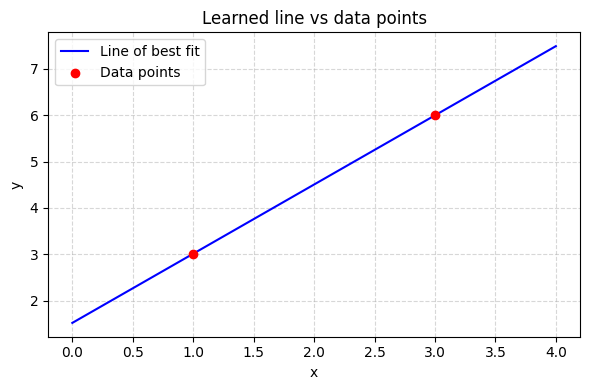

In [17]:
def plot_line_with_points(m: float, b: float, x: np.ndarray, y: np.ndarray) -> None:
    # flatten x and y to 1D for plotting
    x_points = x.flatten()
    y_points = y.flatten()

    # choose a simple range that covers both points
    x_min = x_points.min() - 1.0
    x_max = x_points.max() + 1.0
    x_line = np.linspace(x_min, x_max, 100)
    y_line = m * x_line + b

    plt.figure(figsize=(6, 4))

    # line of best fit
    plt.plot(x_line, y_line, label="Line of best fit", color="blue")

    # original data points
    plt.scatter(x_points, y_points, color="red", label="Data points", zorder=3)

    plt.title("Learned line vs data points")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


plot_line_with_points(m_final, b_final, x_train, y_train)

## Section 8 - Scipy Optimization Check

We use the scipy.optimize function to compare our final `m` and `b` with the optimized/best values for minimizing our mean squared error

In [18]:
from scipy import optimize

def mse_params(params: np.ndarray, x: np.ndarray, y: np.ndarray) -> float:
    m_val, b_val = params

    return mean_squared_error(m_val, b_val, x, y)

# We are passing the initial `m` and `b` values
initial_params = np.array([-1, 1])

result = optimize.minimize(
    fun=mse_params,
    x0=initial_params,
    args=(x_train, y_train),
)

m_scipy, b_scipy = result.x

print("SciPy optimum m, b:", m_scipy, ", ", b_scipy)
print("Manual Gradient Descent m, b    :", m_final,", ", b_final)

print("\n\nSciPy MSE         :", result.fun)
print("Manual Gradient Descent MSE     :", history["error"][-1])

SciPy optimum m, b: 1.499999985165983 ,  1.5000000393944612
Manual Gradient Descent m, b    : 1.4888913653180544 ,  1.5268186165086013


SciPy MSE         : 3.1465145053771267e-16
Manual Gradient Descent MSE     : 0.00014457416004305906
